<a href="https://colab.research.google.com/github/AnkitaRooj/DSA/blob/main/BOW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/My Drive/nlp_notebooks/bow/dataset/spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.isna().sum()

,0
Category,0
Message,0


In [7]:
df.duplicated().sum()

np.int64(415)

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df['Message'].apply(lambda x : x.endswith(' ') or x.startswith(' ')).sum()

np.int64(1)

In [10]:
df['Message'] = df['Message'].apply(lambda x : x.strip())

In [11]:
df[df['Message'].str.strip() == '']

,Category,Message


In [20]:
print(df['Message'].str.contains('..').sum())
df['Message'] = df['Message'].apply(lambda x : x.replace("..","."))

5157


In [21]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy. Available only i..."
1,ham,Ok lar.. Joking wif u oni..
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor.. U c already then say..
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
print(df['Message'].str.contains('...').sum())
print(df['Message'].str.contains('....').sum())
print(df['Message'].str.contains('.....').sum())
print(df['Message'].str.contains('......').sum())
print(df['Message'].str.contains('.......').sum())

5155
5151
5148
5146
5141


In [35]:
text = df['Message'].loc[0]
exp = r'\.+'
dot_counts = len(re.findall(exp,text))
dot_counts
free_dots = re.sub(exp,'.',text)
free_dots


'Go until jurong point, crazy. Available only in bugis n great world la e buffet. Cine there got amore wat.'

In [37]:
def count_replace_dots(text):
  exp=r'\.+'
  dot_counts = len(re.findall(exp,text))
  free_dots = re.sub(exp,'.',text)
  return dot_counts, free_dots

df[['seriesDot_count','clean_msg']] = df['Message'].apply(count_replace_dots).tolist()
df.head()

,Category,Message,dot_series_count,cleaned_message,seriesDot_count,clean_msg
0,ham,"Go until jurong point, crazy. Available only i...",3,"Go until jurong point, crazy. Available only i...",3,"Go until jurong point, crazy. Available only i..."
1,ham,Ok lar.. Joking wif u oni..,2,Ok lar. Joking wif u oni.,2,Ok lar. Joking wif u oni.
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,Free entry in 2 a wkly comp to win FA Cup fina...,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor.. U c already then say..,2,U dun say so early hor. U c already then say.,2,U dun say so early hor. U c already then say.
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,"Nah I don't think he goes to usf, he lives aro...",0,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
df.drop(columns=['dot_series_count','cleaned_message'],inplace=True)
df.head()

,Category,Message,seriesDot_count,clean_msg
0,ham,"Go until jurong point, crazy. Available only i...",3,"Go until jurong point, crazy. Available only i..."
1,ham,Ok lar.. Joking wif u oni..,2,Ok lar. Joking wif u oni.
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor.. U c already then say..,2,U dun say so early hor. U c already then say.
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,"Nah I don't think he goes to usf, he lives aro..."


In [39]:
df['clean_msg'].str.contains('\n').sum()

np.int64(1)

In [40]:
df['clean_msg'] = df['clean_msg'].apply(lambda x: x.replace('\n',' '))

In [41]:
df['clean_msg'].str.contains('\n').sum()

np.int64(0)

In [43]:
import string
df['clean_msg'].str.contains(string.punctuation, regex=False).sum()

np.int64(0)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Category         5157 non-null   object
 1   Message          5157 non-null   object
 2   seriesDot_count  5157 non-null   object
 3   clean_msg        5157 non-null   object
dtypes: object(4)
memory usage: 330.5+ KB


In [46]:
df['Category'].value_counts()

,count
Category,
ham,4516
spam,641


In [47]:
df['Category_codes'] = np.where(df['Category']=='spam',1,0)
df.head()

,Category,Message,seriesDot_count,clean_msg,Category_codes
0,ham,"Go until jurong point, crazy. Available only i...",3,"Go until jurong point, crazy. Available only i...",0
1,ham,Ok lar.. Joking wif u oni..,2,Ok lar. Joking wif u oni.,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor.. U c already then say..,2,U dun say so early hor. U c already then say.,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,"Nah I don't think he goes to usf, he lives aro...",0


In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df['clean_msg'],df['Category_codes'],test_size=0.2,random_state=42)

In [49]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_train_cv.shape

(4125, 7607)

In [50]:
dir(cv)

['_CountVectorizer__metadata_request__fit',
 '_CountVectorizer__metadata_request__transform',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_char_ngrams',
 '_char_wb_ngrams',
 '_check_feature_names',
 '_check_n_features',
 '_check_stop_words_consistency',
 '_check_vocabulary',
 '_count_vocab',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_limit_features',
 '_more_tags',
 '_parameter_constraints',
 '_r

In [51]:
cv.vocabulary_

{'got': 3153,
 'fujitsu': 2994,
 'ibm': 3523,
 'hp': 3474,
 'toshiba': 6856,
 'lot': 4143,
 'of': 4793,
 'model': 4471,
 'how': 3468,
 'to': 6798,
 'say': 5794,
 'so': 6147,
 'are': 1018,
 'you': 7569,
 'really': 5488,
 'what': 7341,
 'up': 7055,
 'the': 6673,
 'masters': 4299,
 'and': 932,
 'on': 4835,
 'see': 5854,
 'cup': 2089,
 'coffee': 1853,
 'animation': 940,
 'this': 6714,
 'pain': 4950,
 'couldn': 2004,
 'have': 3308,
 'come': 1880,
 'at': 1085,
 'worse': 7465,
 'time': 6762,
 'also': 898,
 'where': 7351,
 'piece': 5105,
 'very': 7133,
 'importantly': 3574,
 'all': 882,
 'we': 7281,
 'discuss': 2322,
 'is': 3684,
 'between': 1306,
 'only': 4844,
 'great': 3188,
 'new': 4663,
 'offer': 4798,
 'double': 2386,
 'mins': 4412,
 'txt': 6962,
 'best': 1297,
 'orange': 4874,
 'tariffs': 6572,
 'get': 3072,
 'latest': 3959,
 'camera': 1604,
 'phones': 5087,
 'free': 2941,
 'call': 1584,
 'mobileupd8': 4464,
 '08000839402': 41,
 'now': 4744,
 'or': 4871,
 '2stoptxt': 390,
 'cs': 2064,
 

In [52]:
cv.get_feature_names_out()[6170]

'something'

In [53]:
X_train_cv = X_train_cv.toarray()

In [59]:
X_train[0]

'Go until jurong point, crazy. Available only in bugis n great world la e buffet. Cine there got amore wat.'

In [57]:
X_train_cv[0]
np.where(X_train_cv[0] != 0)

(array([2994, 3153, 3468, 3474, 3523, 4143, 4471, 4793, 5794, 6798, 6856]),)

In [60]:
cv.get_feature_names_out()[2994]

'fujitsu'

In [61]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_cv,y_train)

MultinomialNB()

In [63]:
X_test_cv=cv.transform(X_test).toarray()


In [64]:
y_pred = model.predict(X_test_cv)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [69]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9883720930232558
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       896
           1       0.96      0.96      0.96       136

    accuracy                           0.99      1032
   macro avg       0.97      0.97      0.97      1032
weighted avg       0.99      0.99      0.99      1032



<Axes: >

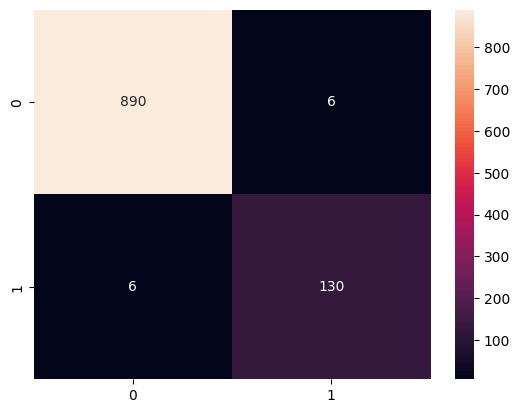

In [71]:
cnf_mat = confusion_matrix(y_test,y_pred)
sns.heatmap(cnf_mat,annot=True,fmt='g')

In [72]:
from sklearn.pipeline import Pipeline
clf = Pipeline([
                ('vectorizer',CountVectorizer()),
                ('nb',MultinomialNB())
])

In [74]:
clf.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [77]:
print(classification_report(y_test,clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       896
           1       0.96      0.96      0.96       136

    accuracy                           0.99      1032
   macro avg       0.97      0.97      0.97      1032
weighted avg       0.99      0.99      0.99      1032



In [79]:
df['word_count'] = df['clean_msg'].apply(lambda x : len(x.split(' ')))

In [80]:
df.head()

,Category,Message,seriesDot_count,clean_msg,Category_codes,word_count
0,ham,"Go until jurong point, crazy. Available only i...",3,"Go until jurong point, crazy. Available only i...",0,20
1,ham,Ok lar.. Joking wif u oni..,2,Ok lar. Joking wif u oni.,0,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,Free entry in 2 a wkly comp to win FA Cup fina...,1,28
3,ham,U dun say so early hor.. U c already then say..,2,U dun say so early hor. U c already then say.,0,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,"Nah I don't think he goes to usf, he lives aro...",0,13
